# Inferring the progenitor of a recoiling SMBH: JWST RBH-1

**RBH-1** is a candidate recoiling supermassive black hole identified in
HST/JWST imaging by Islam, Venumadhav & Wadekar (2026,
[arXiv:2601.18986](https://arxiv.org/abs/2601.18986)), with an inferred
recoil velocity of

$$v_{\rm kick} = 954^{+110}_{-126}\ {\rm km\,s^{-1}}.$$

Such a large recoil can only come from a fairly specific progenitor —
high, misaligned spins and near-comparable masses. We **infer the
progenitor** mass ratio and spin magnitudes from the measured kick with
`gwGenealogy.core.KickToProgenitor`, which inverts the IW2025
precessing-kick flow.

The flow is a *conditional* density $p(v_{\rm kick}\,|\,q, a_1, a_2)$
(spin angles marginalised internally). `KickToProgenitor` uses it as a
likelihood and applies Bayes,

$$p(q,a_1,a_2\,|\,d) \propto \Big[\int p(d\,|\,v)\,p(v\,|\,q,a_1,a_2)\,dv\Big]\,\pi(q,a_1,a_2),$$

marginalising the (asymmetric) measurement uncertainty $p(d\,|\,v)$ and
importance-sampling over the prior $\pi$.

In [1]:
import warnings
warnings.filterwarnings('ignore', 'Wswiglal-redir-stdio')

import numpy as np
import matplotlib.pyplot as plt

from gwGenealogy.core import KickToProgenitor
from gwGenealogy.utils import set_rcparams

set_rcparams()

lal.MSUN_SI != Msun


## Set up and run the inversion

The $954^{+110}_{-126}$ km/s error bar is asymmetric, so we pass
`sigma_lo=126` and `sigma_hi=110` — `KickToProgenitor` models the
measurement as a split normal and marginalises over the true kick. Priors:
$q\sim\mathcal{U}[1,20]$, $a_1, a_2\sim\mathcal{U}[0,1]$ (the defaults).

In [2]:
k2p = KickToProgenitor(
    v_kicks=954.0, sigma_lo=126.0, sigma_hi=110.0,
    q_min=1.0, q_max=20.0,            # spins default to U[0, 1]
    n_prior=300_000, n_posterior=40_000, seed=0)
print(k2p)

results = k2p.infer(verbose=True)

summary = k2p.summary(ci=90)
print('\nRBH-1 progenitor (median, 90% CI):')
for p in ('q', 'a1', 'a2'):
    print(f'  {p:>3s} = {summary[p + "_median"][0]:5.2f}  '
          f'[{summary[p + "_low"][0]:.2f}, {summary[p + "_high"][0]:.2f}]')

KickToProgenitor(n_kicks=1, Gaussian errors, n_prior=300000, n_posterior=40000)


  kick 1/1: v=954 km/s  ESS=40805/300000  -> q=3.01, a1=0.79, a2=0.52

RBH-1 progenitor (median, 90% CI):
    q =  3.01  [1.17, 6.88]
   a1 =  0.79  [0.41, 0.98]
   a2 =  0.52  [0.05, 0.93]


## Progenitor posterior

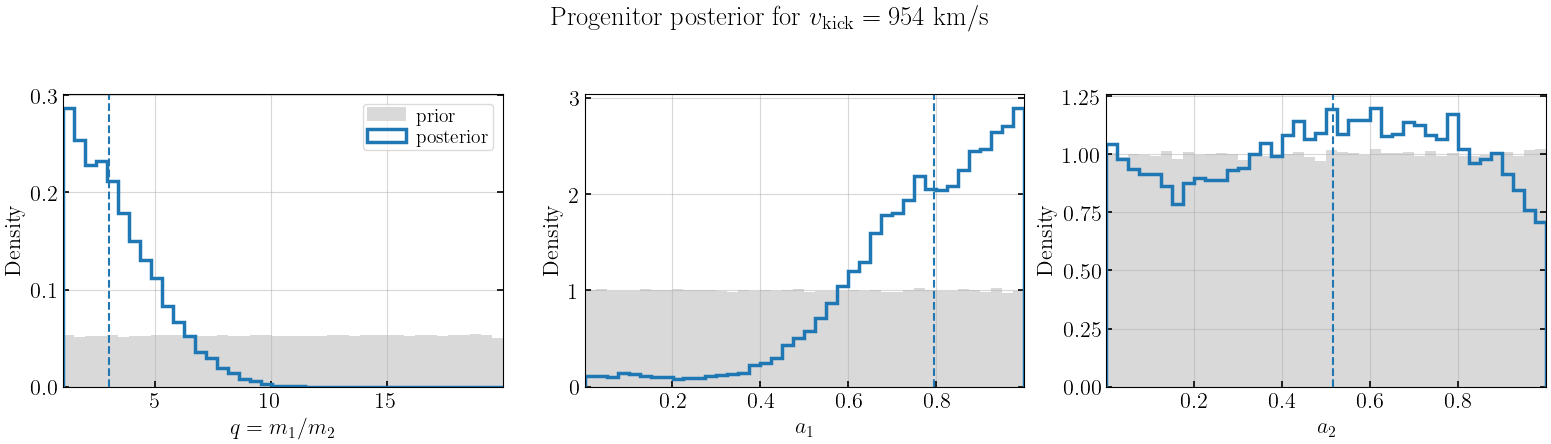

In [3]:
fig, axes = k2p.plot_posteriors(index=0)
plt.show()

The large recoil drives the **primary spin high** ($a_1 \approx 0.8$,
disfavouring $a_1 \lesssim 0.4$) and favours **comparable masses**
($q$ peaks near 2–3). The secondary spin $a_2$ is only weakly constrained.
The $q$ posterior sits well below the prior's upper edge, so the
$q \le 20$ bound is immaterial and we stay within the flow's calibrated
range ($q \lesssim 14$).

## Posterior-predictive check

`posterior_predictive` draws one kick from each posterior progenitor.
Because the flow **marginalises over spin orientation**, a single
$(q, a_1, a_2)$ maps to a *broad* kick distribution — the same progenitor
can recoil at very different speeds depending on the (unobserved) spin
geometry. So the predictive distribution is wide and not sharply peaked at
954 km/s: the inference constrains masses and spin magnitudes, not the
spin angles that set the exact recoil.

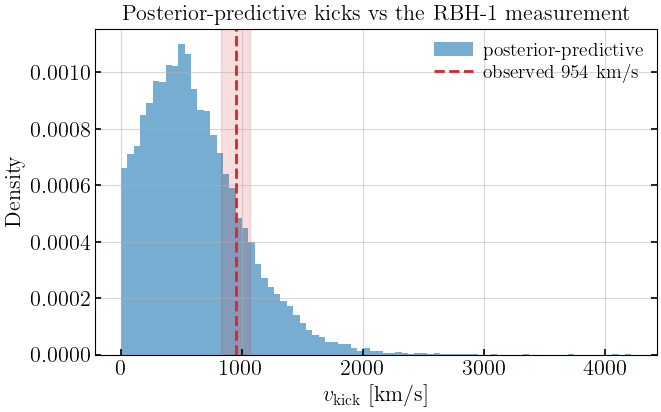

posterior-predictive kick: median=554  90% CI=[73, 1380] km/s


In [4]:
vk_pp = k2p.posterior_predictive(index=0, n=20000, seed=1)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(vk_pp, bins=80, density=True, alpha=0.6, label='posterior-predictive')
ax.axvline(954, color='C3', ls='--', lw=2, label=r'observed $954$ km/s')
ax.axvspan(954 - 126, 954 + 110, color='C3', alpha=0.15)
ax.set_xlabel(r'$v_{\rm kick}$ [km/s]'); ax.set_ylabel('Density')
ax.set_title('Posterior-predictive kicks vs the RBH-1 measurement')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

print(f'posterior-predictive kick: median={np.median(vk_pp):.0f}  '
      f'90% CI=[{np.percentile(vk_pp, 5):.0f}, {np.percentile(vk_pp, 95):.0f}] km/s')

## Many kicks at once

`KickToProgenitor` accepts an **array** of kicks and returns a posterior
for each (here treated as exact, `sigma=None`). The inferred primary spin
rises monotonically with the recoil — the expected trend.

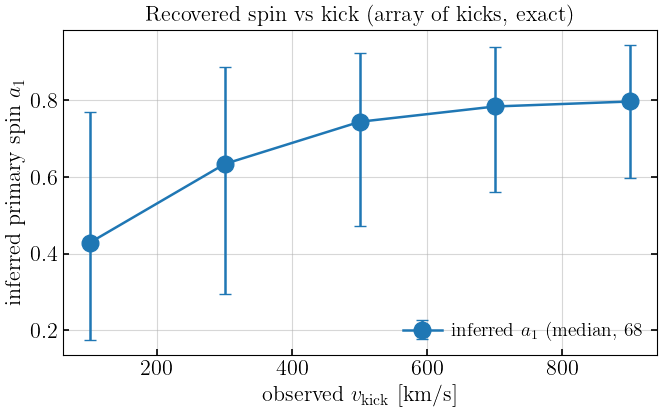

In [5]:
v_arr = np.array([100, 300, 500, 700, 900])
multi = KickToProgenitor(v_arr, q_min=1, q_max=20,
                         n_prior=200_000, n_posterior=20_000, seed=0)
multi.infer()
ms = multi.summary(ci=68)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(v_arr, ms['a1_median'],
            yerr=[ms['a1_median'] - ms['a1_low'], ms['a1_high'] - ms['a1_median']],
            fmt='C0-o', capsize=4, label=r'inferred $a_1$ (median, 68%)')
ax.set_xlabel(r'observed $v_{\rm kick}$ [km/s]')
ax.set_ylabel(r'inferred primary spin $a_1$')
ax.set_title('Recovered spin vs kick (array of kicks, exact)')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## Caveats

- **Posterior, not a unique progenitor.** The recoil is a many-to-one
  function of $(q, a_1, a_2)$ and the spin angles, so the widths above are
  real physical degeneracy.
- **Spin tilts are unrecoverable.** The flow's context is only
  $(q, a_1, a_2)$; the tilt/azimuth dependence is marginalised inside it.
  We constrain spin *magnitudes* and mass ratio, never the orientations.
- **Prior-dependent.** `KickToProgenitor` takes a range + distribution or
  an explicit prior array per parameter; an astrophysically motivated
  SMBH-merger prior would sharpen or shift the result. Watch the `ess` —
  kicks in the model's far tail thin the prior pool and need a larger
  `n_prior`.
- **Single-event inference.** Each kick is treated independently; a
  population of recoiling SMBHs would call for hierarchical inference.